In [1]:
import os, re, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset
from transformers import (
    GPT2LMHeadModel, GPT2Tokenizer,
    Trainer, TrainingArguments,
    EarlyStoppingCallback,
)

warnings.filterwarnings('ignore')

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
DATA_PATH = Path('/content/drive/MyDrive/Colab Notebooks/ReviewGeneration/data/Amazon_Reviews.csv')
MODEL_DIR = Path('/content/drive/MyDrive/Colab Notebooks/ReviewGeneration/model')
METADATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/ReviewGeneration/model')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)

In [18]:
BOS_PROMPT = '|<prompt>|'
BOS_REVIEW = '|<review>|'
EOS_TOKEN = '|<endoftext>|'

In [19]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE.upper())

Device: CUDA


In [20]:
df = pd.read_csv(DATA_PATH, sep=None, engine='python', on_bad_lines='warn')
print('Size: ', df.shape)
print('Columns: ', list(df.columns))
df.head(3)

Size:  (21214, 9)
Columns:  ['Reviewer Name', 'Profile Link', 'Country', 'Review Count', 'Review Date', 'Rating', 'Review Title', 'Review Text', 'Date of Experience']


,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"


In [21]:
print(df.isnull().sum())

df = df.dropna(subset=['Review Text', 'Rating'])

df['Country']      = df['Country'].fillna('Unknown')
df['Review Title'] = df['Review Title'].fillna('General')

df = df[['Reviewer Name', 'Country', 'Rating',
         'Review Title', 'Review Text']].copy()

print(f'После очистки: {len(df):,} строк')
print(f'Пропусков осталось:\n{df.isnull().sum()}')

Reviewer Name           0
Profile Link           51
Country               160
Review Count          159
Review Date           159
Rating                159
Review Title          159
Review Text           159
Date of Experience    267
dtype: int64
После очистки: 21,055 строк
Пропусков осталось:
Reviewer Name    0
Country          0
Rating           0
Review Title     0
Review Text      0
dtype: int64


In [22]:
def extract_rating_int(s):
    m = re.search(r'(\d+)', str(s))
    return int(m.group(1)) if m else None

In [23]:
df['rating_int'] = df['Rating'].apply(extract_rating_int)
df['text_len'] = df['Review Text'].astype(str).apply(len)

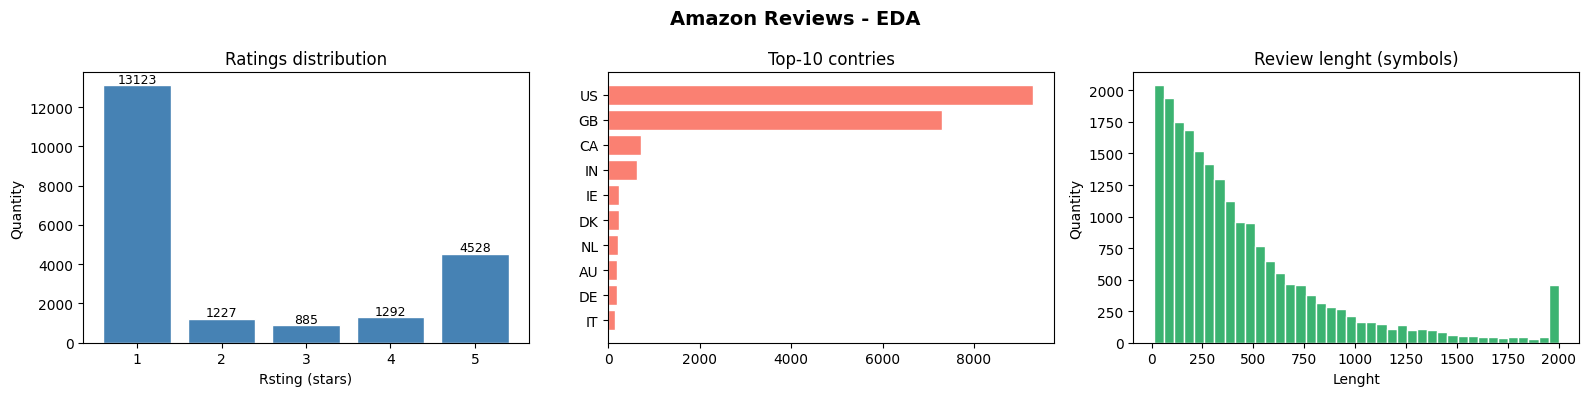

Average review length: 461 symbols


In [24]:
fig, axes = plt.subplots(1, 3, figsize = (16, 4))
rc = df['rating_int'].value_counts().sort_index()
axes[0].bar(rc.index.astype(str), rc.values, color='steelblue', edgecolor='white')
axes[0].set_title('Ratings distribution')
axes[0].set_xlabel('Rsting (stars)')
axes[0].set_ylabel('Quantity')
for i, v in enumerate(rc.values):
    axes[0].text(i, v + max(rc.values)*0.01, str(v), ha='center', fontsize=9)

tc = df['Country'].value_counts().head(10)
axes[1].barh(tc.index, tc.values, color='salmon', edgecolor='white')
axes[1].set_title('Top-10 contries')
axes[1].invert_yaxis()

axes[2].hist(df['text_len'].clip(0, 2000), bins=40, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Review lenght (symbols)')
axes[2].set_xlabel('Lenght')
axes[2].set_ylabel('Quantity')

plt.suptitle('Amazon Reviews - EDA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(METADATA_DIR / 'dataset_stats.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Average review length: {df["text_len"].mean():.0f} symbols')

In [25]:
def exrtract_topic(title_str):
    s = str(title_str).strip()
    s = re.sub(r'Rated \d+ out of \d+ stars, ?\s*', '', s). strip()
    return s if len(s) > 1 else 'General'

def clean_text(text):
    return re.sub(r'\s+',' ', str(text).strip())

In [26]:
df = df.dropna(subset=['Review Text', 'Rating']).copy()
df['rating_int'] = df['Rating'].apply(extract_rating_int)
df = df.dropna(subset=['rating_int'])
df['rating_int'] = df['rating_int'].astype(int)

df['topic'] = df['Review Title'].apply(exrtract_topic)
df['clean_text'] = df['Review Text'].apply(clean_text)
df['country'] = df['Country'].fillna('Unknown').str.strip()

df = df[df['clean_text'].str.len() >= 30].reset_index(drop=True)

print('After cleaning:', len(df), 'strings')
print('Ratings: ', sorted(df['rating_int'].unique()))
print('Unique countries: ', df['country'].nunique())

After cleaning: 20087 strings
Ratings:  [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Unique countries:  144


In [27]:
def make_trainig_text(row):
    return (
        f"{BOS_PROMPT} "
        f"RATING:{row['rating_int']} "
        f"COUNTRY:{row['country']} "
        f"TOPIC:{row['topic']} "
        f"{BOS_REVIEW} "
        f"{row['clean_text']}"
        f"{EOS_TOKEN}"
    )

df['training_text'] = df.apply(make_trainig_text, axis = 1)

print('Promt examples:')
for i in range(2):
    print(df['training_text'].iloc[i][:300])

Promt examples:
|<prompt>| RATING:1 COUNTRY:US TOPIC:A Store That Doesn't Want to Sell Anything |<review>| I registered on the website, tried to order a laptop, entered all the details, but instead of charging me and sending the product, they froze my account, demanding various verification documents. I sent them o
|<prompt>| RATING:1 COUNTRY:GB TOPIC:Had multiple orders one turned up and… |<review>| Had multiple orders one turned up and driver had to phone as no door number on packaging, then waited all day for second package to get a message saying couldn't deliver as no number on packaging, 12 hours waiting


In [28]:
metadata = {
    'unique_countries': sorted(df['country'].unique().tolist()),
    'unique_topics':    sorted(df['topic'].unique().tolist()),
    'rating_range':     [int(df['rating_int'].min()), int(df['rating_int'].max())],
    'n_samples':        len(df),
    'bos_prompt':       BOS_PROMPT,
    'bos_review':       BOS_REVIEW,
    'eos_token':        EOS_TOKEN,
    'model_dir':        str(MODEL_DIR),
}

with open(METADATA_DIR / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print('Countries: ', len(metadata['unique_countries']))
print('Themes: ', len(metadata['unique_topics']))
print('Countries Examples: ', metadata['unique_countries'][:5])

Countries:  144
Themes:  18483
Countries Examples:  ['AD', 'AE', 'AF', 'AG', 'AM']


In [29]:
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED)

print('Train: ', len(train_df))
print('Val: ', len(val_df))
print('Test: ', len(test_df))

test_df.to_csv(METADATA_DIR / 'test_split.csv', index = False)
print('test_split.csv saved')

Train:  16069
Val:  2009
Test:  2009
test_split.csv saved


In [30]:
MODEL_NAME = 'distilgpt2'
MAX_LENGTH = 256

tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)
tokenizer.add_special_tokens({
    'pad_token': '<|pad|>',
    'additional_special_tokens': [BOS_PROMPT, BOS_REVIEW]
})

print('Dict size: ', len(tokenizer), ' tokens')

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Dict size:  50260  tokens


In [31]:
sample = df['training_text'].iloc[0]
enc = tokenizer(sample, max_lenght = MAX_LENGTH, truncation=True)
print('Example:', len(enc['input_ids']), 'tokens from', MAX_LENGTH, 'max')

Example: 160 tokens from 256 max


In [32]:
class ReviewDataset(Dataset):

    def __init__(self, texts, tokenizer, max_length = 256):
        self.encodings = tokenizer(
            texts,
            max_length = max_length,
            truncation = True,
            padding = 'max_length',
            return_tensors = 'pt'
        )
        self.pad_id = tokenizer.pad_token_id

    def __len__(self):
        return self.encodings['input_ids'].shape[0]

    def __getitem__(self, index):
        item = {k: v[index] for k, v in self.encodings.items()}
        labels = item['input_ids'].clone()
        labels[labels == self.pad_id] = -100
        item['labels'] = labels
        return item

print('Train tokenization...')
train_dataset = ReviewDataset(train_df['training_text'].to_list(), tokenizer, MAX_LENGTH)
print('Validation tokemization...')
val_dataset = ReviewDataset(val_df['training_text'].to_list(), tokenizer, MAX_LENGTH)

print('Train:', len(train_dataset), 'examples')
print('Val:', len(val_dataset), 'examples')


Train tokenization...
Validation tokemization...
Train: 16069 examples
Val: 2009 examples


In [33]:
model = GPT2LMHeadModel.from_pretrained(MODEL_NAME)
model.resize_token_embeddings(len(tokenizer))
model = model.to(DEVICE)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('Overall parameters:', total)
print('Trainable:', trainable)

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Overall parameters: 81914880
Trainable: 81914880


In [34]:
BATCH_SIZE = 32
GRAD_ACCUM = 2
EPOCHS = 5
LR = 5e-5
WARMUP_STEPS = 50
EVAL_STEPS = 200
SAVE_STEPS = 200
LOGGING_STEPS = 50

In [35]:
training_args = TrainingArguments(
    output_dir= str(MODEL_DIR),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_steps=WARMUP_STEPS,
    weight_decay=0.01,
    logging_dir=str(MODEL_DIR / 'logs'),
    logging_steps=LOGGING_STEPS,
    eval_strategy='steps',
    eval_steps = EVAL_STEPS,
    save_strategy='steps',
    save_steps = SAVE_STEPS,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    fp16=True,
    use_cpu= False,
    report_to = 'none',
    seed = SEED,
    dataloader_num_workers=2
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [36]:
trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset = val_dataset,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)]
)

In [37]:
print('Strating training...')
print(f'Effective Batch: {BATCH_SIZE} * {GRAD_ACCUM} = {BATCH_SIZE*GRAD_ACCUM}')
train_result = trainer.train()

print('Results')
print('Train Loss:', train_result.training_loss)
print('Time (sec):', train_result.metrics['train_runtime'])

Strating training...
Effective Batch: 32 * 2 = 64


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss,Validation Loss
200,3.213367,3.079841
400,3.109889,3.012156
600,3.058883,2.980855
800,2.994109,2.968259
1000,2.987653,2.956554
1200,2.977149,2.953195


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Results
Train Loss: 3.1049571052430167
Time (sec): 1319.5034


In [46]:
trainer.save_model(str(MODEL_DIR))
tokenizer.save_pretrained(str(MODEL_DIR))

eos_token_id = tokenizer.eos_token_id
pad_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else eos_token_id

gen_config = {
    'max_new_tokens': 200,
    'do_sample': True,
    'temperature': 0.6
    'top_p': 0.85,
    'top_k': 50,
    'repetition_penalty': 1.1,
    'eos_token_id': eos_token_id,
    'pad_token_id': pad_token_id,


}

with open(MODEL_DIR / 'gen_config.json', 'w') as f:
    json.dump(gen_config, f, indent = 2)

print("Model saved:", MODEL_DIR)
print(f'Files: {[p.name for p in MODEL_DIR.iterdir()]}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved: /content/drive/MyDrive/Colab Notebooks/ReviewGeneration/model
Files: ['dataset_stats.png', 'metadata.json', 'test_split.csv', 'checkpoint-1200', 'checkpoint-1260', 'config.json', 'generation_config.json', 'model.safetensors', 'training_args.bin', 'tokenizer_config.json', 'tokenizer.json', 'gen_config.json', 'training_curves.png']


Финальная Val Perplexity: 19.17


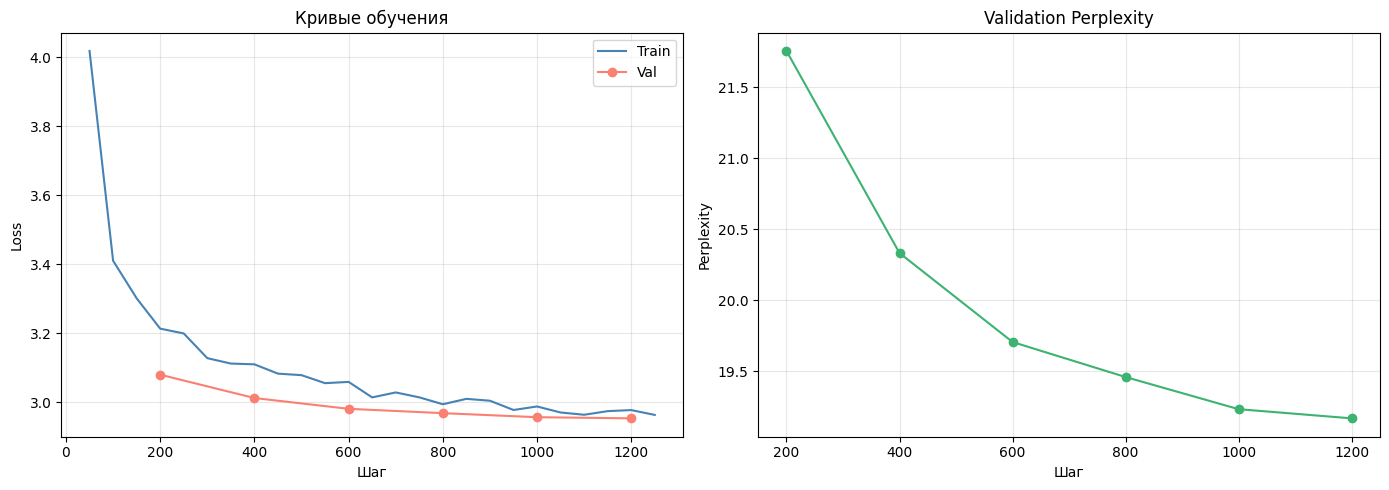

In [47]:
log = trainer.state.log_history

t_steps  = [e['step'] for e in log if 'loss' in e and 'eval_loss' not in e]
t_losses = [e['loss'] for e in log if 'loss' in e and 'eval_loss' not in e]
v_steps  = [e['step'] for e in log if 'eval_loss' in e]
v_losses = [e['eval_loss'] for e in log if 'eval_loss' in e]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(t_steps, t_losses, label='Train', color='steelblue')
if v_steps:
    axes[0].plot(v_steps, v_losses, label='Val', color='salmon', marker='o')
axes[0].set_xlabel('Шаг')
axes[0].set_ylabel('Loss')
axes[0].set_title('Кривые обучения')
axes[0].legend()
axes[0].grid(alpha=0.3)

if v_losses:
    v_ppl = [np.exp(l) for l in v_losses]
    axes[1].plot(v_steps, v_ppl, color='mediumseagreen', marker='o')
    axes[1].set_xlabel('Шаг')
    axes[1].set_ylabel('Perplexity')
    axes[1].set_title('Validation Perplexity')
    axes[1].grid(alpha=0.3)
    print(f'Финальная Val Perplexity: {v_ppl[-1]:.2f}')

plt.tight_layout()
plt.savefig(METADATA_DIR / 'training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

In [50]:
def generate_review(rating, country, topic, model, tokenizer, gen_cfg, device='cpu'):
    """
    Генерирует текст отзыва по заданным условиям.

    Args:
        rating  (int)  : 1–5
        country (str)  : код страны, напр. 'GB', 'US'
        topic   (str)  : тема отзыва, напр. 'Delivery issues'

    Returns:
        str: текст сгенерированного отзыва
    """
    prompt = (
        f"{BOS_PROMPT} "
        f"RATING:{rating} "
        f"COUNTRY:{country} "
        f"TOPIC:{topic} "
        f"{BOS_REVIEW} "
    )
    inputs = tokenizer(prompt, return_tensors='pt').to(device)
    model.eval()
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            **gen_cfg,
        )
    full_text = tokenizer.decode(output_ids[0], skip_special_tokens=False)

    if BOS_REVIEW in full_text:
        review = full_text.split(BOS_REVIEW)[-1].strip()
    else:
        review = full_text.strip()


    import re

    match = re.search(r'<\s*\/??\s*end\s*of\s*text\s*>', review, flags=re.IGNORECASE)
    if match:

        review = review[:match.start()].strip()

    review = review.rstrip('| ').strip()

    return review


with open(MODEL_DIR / 'gen_config.json') as f:
    gen_cfg = json.load(f)

test_cases = [
    (1, 'GB', 'Delivery issues'),
    (5, 'US', 'Great service'),
    (3, 'DE', 'Product quality'),
]

for rating, country, topic in test_cases:
    print(f'\n{"─"*60}')
    print(f'RATING={rating} | COUNTRY={country} | TOPIC={topic}')
    print('─'*60)
    review = generate_review(rating, country, topic, model, tokenizer, gen_cfg, DEVICE)
    print(review)


────────────────────────────────────────────────────────────
RATING=1 | COUNTRY=GB | TOPIC=Delivery issues
────────────────────────────────────────────────────────────
Delivery issues. I ordered a book and it was delivered to my address on the 21st of March, but Amazon decided to deliver that order in 2 days! The item has been delayed for over 3 weeks now & is still waiting...I have tried contacting them all day asking if they can fix this issue - which means there will be no refund from me as well. They are also very rude at times when you ask why your package hasn't arrived yet? This company should not allow any type of customer service reps who don’t know what's going down their throats

────────────────────────────────────────────────────────────
RATING=5 | COUNTRY=US | TOPIC=Great service
────────────────────────────────────────────────────────────
I have been a Prime member for years and am always satisfied with my product.

──────────────────────────────────────────────────────